# 07_降维技术-局部线性嵌入

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- LLE 调参改为在验证样本的 transform 结果上评估 trustworthiness，修复训练/验证距离矩阵维度不一致的问题。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家聊聊降维算法中的局部线性嵌入\~

首先说，“降维”就是把高维（比如上百、上千个特征）的数据，用更少的维度（比如 2D、3D）来表示，同时尽量保留数据的“形状”或“结构”。

局部线性嵌入（Locally Linear Embedding，简称 LLE）就是一种常用的非线性降维方法，简单来说，就是这样一步步“把复杂的扭曲面展开平铺”：

#### 1. 为什么要用 LLE？

许多实际问题的数据都藏在“低维流形”上：

比如一条在三维空间里蜿蜒的瑞士卷（Swiss Roll）蛋糕，虽然它在 3D 里长得很乱，但本质上它是一张被卷起来的 2D 薄片。

如果我们直接丢掉维度，往往拿不准扭在哪里，数据结构也会乱成一锅粥。

LLE 的目标：**保住每个样本在“小圈子”里的“邻居关系”**，再把这些小圈子整体“铺平”到低维空间。

**三步走：**

1. **找邻居**

   - 对每个点，找出它在原始高维空间里最靠近的 k 个“小伙伴”（常用 k≈5～20）。
   - 类比：在一个拥挤的舞池里，你只和身边最近的几个人互动。
2. **线性重构**

   - 假设一个点可以用它那些 k 个邻居的“线性组合”来逼近（加权平均）。
   - 也就是说，给每个邻居分配一个权重，拼起来最像这个中心点。
   - 这些权重只和局部结构有关，能刻画小区域的“形状”。
3. **全局嵌入**

   - 让我们把所有点都搬到一个低维空间（比如 2D 画布）上，**要求同样的权重**套用在低维上之后，每个点依然能被它那 k 个邻居“拼”出来。
   - 这么做就相当于把原本高维、可能扭曲的流形，在低维里尽可能“平滑”展平。

直观理解，**局部保持 → 全局展开**

- 在小范围里，用直线（线性）去近似复杂曲线是可以的；
- 把每个小范围都“拉平”后，整体的曲面自然就展开了。
- **“瑞士卷”示例**，原本三维里一团扭曲的薄片，通过 LLE，你在 2D 里能看到它原来的“铺开样子”。

## 原理详解

### 流形与降维目标

**流形假设**：

高维数据：$\{\mathbf{x}_1,\dots,\mathbf{x}_N\}\subset\mathbb R^D$

实际上分布在一个光滑的、嵌入于$\mathbb R^D$中的低维流形上（维度 $d\ll D$）。

**降维目标**

找到低维坐标  
$\{\mathbf{y}_1,\dots,\mathbf{y}_N\}\subset\mathbb R^d$  
既保留流形的“局部几何结构”，又尽量展开“全局形状”。

LLE 的核心思想是：用局部线性重构来捕捉邻域结构，再把这些重构权重不变地应用于低维嵌入。**

### 算法整体三步

1. **邻域选择**：对每个样本 $\mathbf{x}_i$，在高维空间中找出其最近的 $K$ 个邻居（通常用欧氏距离）。
2. **线性重构权重求解**：对于每个 $i$，解以下受约束的最小二乘，计算重构权重 $\{w_{ij}\}$：  
$\min_{\{w_{ij}\}}\; \Bigl\|\mathbf{x}_i - \sum_{j\in\mathcal N(i)} w_{ij}\,\mathbf{x}_j\Bigr\|^2,\quad\text{s.t.}\;\sum_{j\in\mathcal N(i)} w_{ij}=1.$
3. **低维嵌入**：固定上述权重 $\{w_{ij}\}$，求低维坐标 $\{\mathbf{y}_i\in\mathbb R^d\}$ 使得同样的重构误差最小：  
$\min_{\{\mathbf{y}_i\}}\sum_{i=1}^N\Bigl\|\mathbf{y}_i - \sum_{j\in\mathcal N(i)} w_{ij}\,\mathbf{y}_j\Bigr\|^2.$  
这一优化可转化为对一个 $N\times N$ 稀疏矩阵的特征分解问题，取最小非平凡特征向量构成嵌入。

### 权重求解的公式推导

#### 构造局部协方差矩阵

对固定 $i$，令邻居集合 $\mathcal N(i)=\{j_1,\dots,j_K\}$。定义局部协方差矩阵


$$
C_i \;=\;\begin{bmatrix}\mathbf{x}_i - \mathbf{x}_{j_1} & \cdots & \mathbf{x}_i - \mathbf{x}_{j_K}\end{bmatrix}^\top\begin{bmatrix}\mathbf{x}_i - \mathbf{x}_{j_1} & \cdots & \mathbf{x}_i - \mathbf{x}_{j_K}\end{bmatrix}\;\in\;\mathbb R^{K\times K}.
$$


它的 $(p,q)$ 元素为 $(\mathbf{x}_i-\mathbf{x}_{j_p})^\top(\mathbf{x}_i-\mathbf{x}_{j_q})$。

#### 最小二乘与拉格朗日法

要最小化


$$
\mathcal L_i(\mathbf w_i,\lambda)= \mathbf w_i^\top C_i\,\mathbf w_i - \lambda\Bigl(\sum_{j\in\mathcal N(i)}w_{ij}-1\Bigr),
$$


其中 $\mathbf w_i=[w_{ij_1},\dots,w_{ij_K}]^\top$。

对 $\mathbf w_i$ 和 $\lambda$ 求导并令零：


$$
\begin{cases}    2\,C_i\,\mathbf w_i - \lambda\,\mathbf 1 = 0,\\    \mathbf 1^\top\mathbf w_i = 1,  \end{cases}  \quad\Longrightarrow\quad  C_i\,\mathbf w_i = \tfrac{\lambda}{2}\,\mathbf 1  ,\;  \mathbf 1^\top \mathbf w_i =1.
$$


解得：


$$
\mathbf w_i = \frac{C_i^{-1}\,\mathbf 1}{\mathbf 1^\top C_i^{-1}\,\mathbf 1}.
$$


若 $C_i$ 奇异，可加小量正则化：


$$
C_i \leftarrow C_i + \varepsilon I
$$


### 低维嵌入的特征分解

#### 二次型表示

将所有样本低维坐标拼成矩阵 $\mathbf Y=[\mathbf y_1,\dots,\mathbf y_N]^\top\in\mathbb R^{N\times d}$。

重构误差总和写作：


$$
\Phi(\mathbf Y)= \sum_{i=1}^N\Bigl\|\mathbf{y}_i - \sum_{j\in\mathcal N(i)} w_{ij}\,\mathbf{y}_j\Bigr\|^2= \mathrm{trace}\bigl(\mathbf Y^\top M\,\mathbf Y\bigr),
$$


其中：

- $M \;=\; (I - W)^\top (I - W)\;\in\;\mathbb R^{N\times N},\quad W_{ij} =\begin{cases}w_{ij}, & j\in\mathcal N(i),\\0, & \text{否则}.\end{cases}$
- $M$ 是对称半正定的稀疏矩阵。

#### 消去平移不变性

- 注意：$\sum_j w_{ij}=1$ 保证了 $M\mathbf 1=\mathbf 0$，即平移不改变误差。
- 因此最小化 $\mathrm{trace}(\mathbf Y^\top M\,\mathbf Y)$ 会出现一个零特征值，对应于$\mathbf 1$。

#### 特征分解求解

在“去中心”并“去掉平移自由度”后，


$$
\min_{\mathbf Y^\top \mathbf Y = I,\,\mathbf Y^\top \mathbf 1 = 0}\mathrm{trace}(\mathbf Y^\top M\,\mathbf Y)
$$


的解，由 $M$ 的**最小**（非零）$d$ 个特征向量构成。

- 取 $M$ 的特征值分解  
$M = U\,\Lambda\,U^\top$，
- 排序 $\lambda_0=0\le\lambda_1\le\lambda_2\le\cdots$.
- 嵌入坐标 $\mathbf y_i$ 为对应于 $\lambda_1,\dots,\lambda_d$ 的特征向量在第 $i$ 行的条目。

### 完整算法流程（伪代码）

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
输入：高维数据 X∈ℝ^{N×D}，邻居数 K，嵌入维度 d
输出：低维坐标 Y∈ℝ^{N×d}

1. 对每个 i=1…N：
     • 计算点 x_i 与其它点的距离，取最近的 K 个索引集 N(i).

2. 对每个 i=1…N：
     • 构造 C_i ∈ ℝ^{K×K}, C_i[p,q] = (x_i - x_{j_p})·(x_i - x_{j_q}).
     • 如有必要，加正则化：C_i ← C_i + ε I.
     • 解 w_i = argmin ‖∑ w_{ij} x_j - x_i‖² s.t. ∑ w_{ij}=1
       —— 公式解：w_i = (C_i^{-1}1) / (1ᵀ C_i^{-1}1).
     • 将 w_i 填入 W 的第 i 行。

3. 构造稀疏矩阵 M = (I−W)ᵀ (I−W).

4. 对 M 做特征分解，取最小非平凡的 d 个特征向量 u₁…u_d。

5. 令 Y = [u₁, …, u_d] ∈ ℝ^{N×d}，并做适当中心化。

返回 Y.
```

### 算法要点与注意

**1. 邻居数** $K$

- 太小：无法捕捉局部结构；
- 太大：远处点被当近邻，引入全局扭曲。

**2. 正则化** $\varepsilon$

- 当邻居共线或 $K>D$ 时，$C_i$ 可能奇异，需加小正则。

**3. 特征分解开销**

- $M$ 非常稀疏，实际可用稀疏特征值求解器（e.g. ARPACK）。

**4. 平移与缩放不变性**

- 嵌入前后，LLE 对于全局平移不敏感；对全局缩放仅改变特征向量大小，通常再做归一化。

总结一下，LLE 通过**局部线性重构权重不变性**，先在高维中为每个样本计算与邻居的最优线性近似，再在低维空间中用同样的权重要求复原，从而“展开”流形。

## 完整案例

整个案例代码，包含数据生成、降维分析、可视化优化和算法改进。

代码使用Swiss Roll数据集进行演示，并通过多维度对比展示算法效果。

### 1. 数据生成与可视化

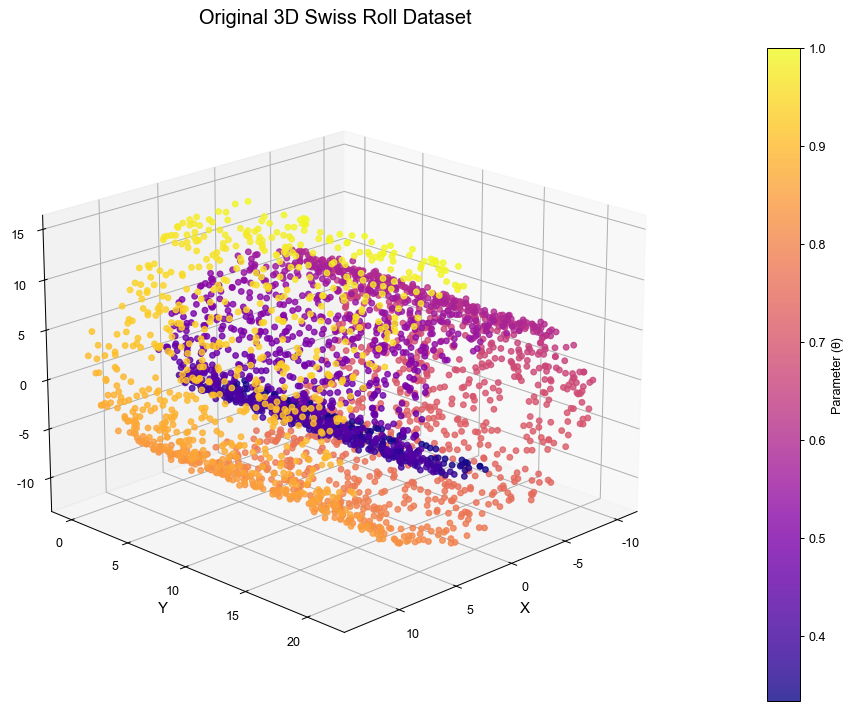

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.datasets import make_swiss_roll

# 生成Swiss Roll数据集
np.random.seed(42)
X, color = make_swiss_roll(n_samples=3000, noise=0.25)
color = color / np.max(color)  # 归一化颜色值

# 3D可视化
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=cm.plasma, s=20, alpha=0.8)
ax.view_init(elev=20, azim=45)
ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_zlabel('Z', fontsize=12, fontweight='bold')
ax.set_title('Original 3D Swiss Roll Dataset', fontsize=16, pad=20)
plt.colorbar(sc, label='Parameter (θ)', pad=0.1)
plt.tight_layout()
plt.show()

Swiss Roll是一个经典的流形学习测试数据集，其三维结构在二维空间中展开后应呈现连续的螺旋形状。

将数据点在三维空间中的角度参数（θ）映射为颜色，增强数据分布的直观性。过程中通过`noise=0.25`向数据添加随机扰动，模拟真实场景中的噪声干扰。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

### 2. 标准LLE算法实现

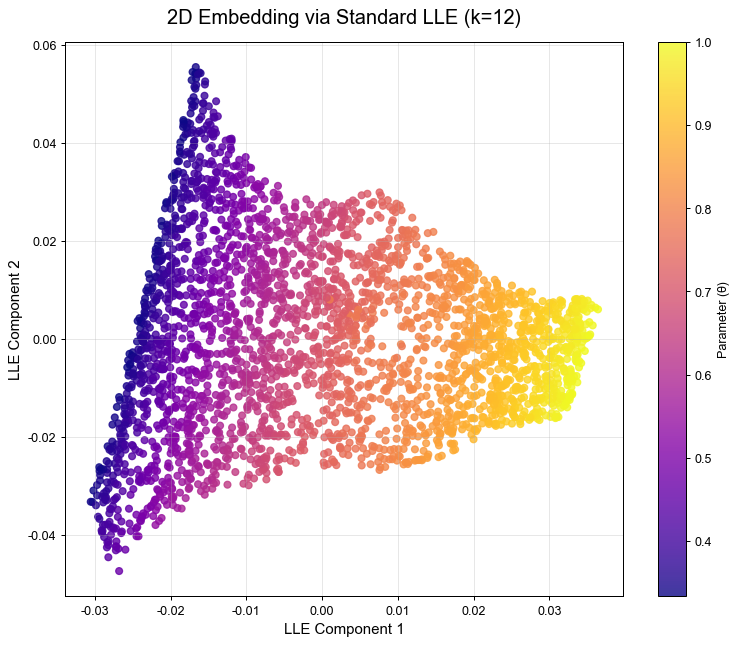

In [3]:
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler

# 数据标准化
X_scaled = StandardScaler().fit_transform(X)

# 标准LLE降维
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=12, method='standard', random_state=42)
X_lle = lle.fit_transform(X_scaled)

# 降维结果可视化
plt.figure(figsize=(10, 8))
plt.scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap=cm.plasma, s=30, alpha=0.8)
plt.xlabel('LLE Component 1', fontsize=12, fontweight='bold')
plt.ylabel('LLE Component 2', fontsize=12, fontweight='bold')
plt.title('2D Embedding via Standard LLE (k=12)', fontsize=16, pad=15)
plt.colorbar(label='Parameter (θ)')
plt.grid(alpha=0.3)
plt.show()

使用`StandardScaler`消除量纲差异，提升数值稳定性。`n_neighbors=12`控制局部线性关系的邻域大小，直接影响流形展开的平滑度。

标准LLE在此参数下可能出现局部扭曲（见下图），需进一步优化。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

### 3. 降维结果分析

可视化对比（不同邻居数k）

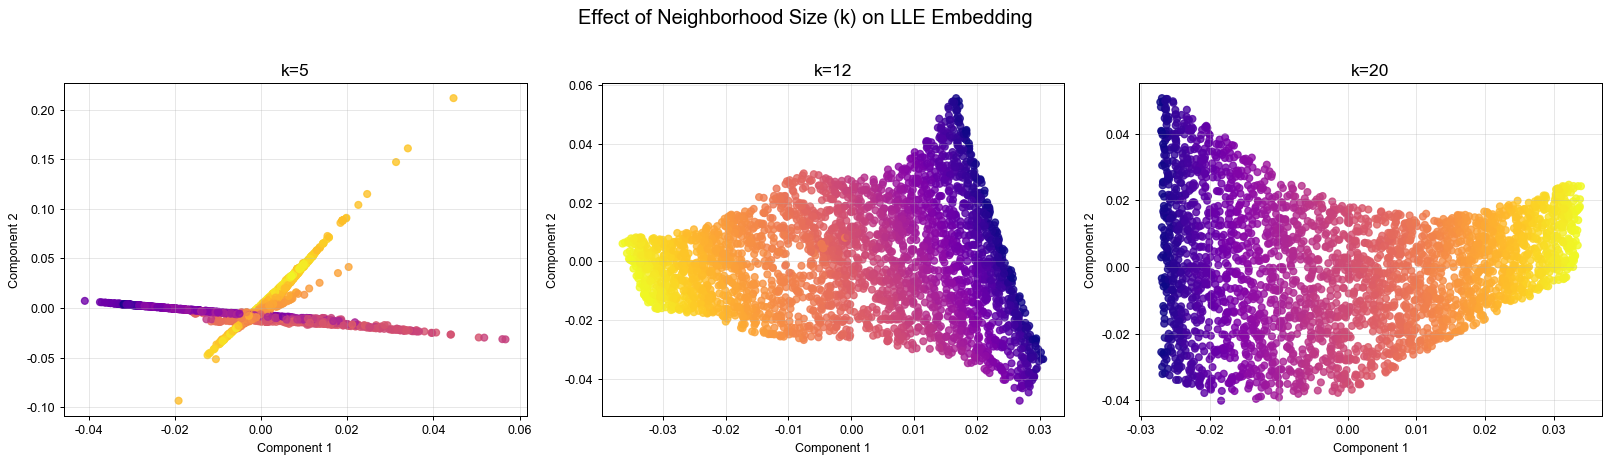

In [4]:
# 测试不同k值对结果的影响
k_values = [5, 12, 20]
plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    lle = LocallyLinearEmbedding(n_components=2, n_neighbors=k, method='standard')
    X_lle = lle.fit_transform(X_scaled)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap=cm.plasma, s=30, alpha=0.8)
    plt.title(f'k={k}', fontsize=14)
    plt.xlabel('Component 1', fontsize=10)
    plt.ylabel('Component 2', fontsize=10)
    plt.grid(alpha=0.3)

plt.suptitle('Effect of Neighborhood Size (k) on LLE Embedding', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_016.png)

- **k=5**：邻域过小导致局部结构碎片化，全局连续性差。
- **k=20**：邻域过大引入远端点干扰，产生异常扭曲。
- **核心矛盾**：需要在局部线性保持与全局结构完整间取得平衡。

### 4. 算法优化策略

#### 优化1：Modified LLE

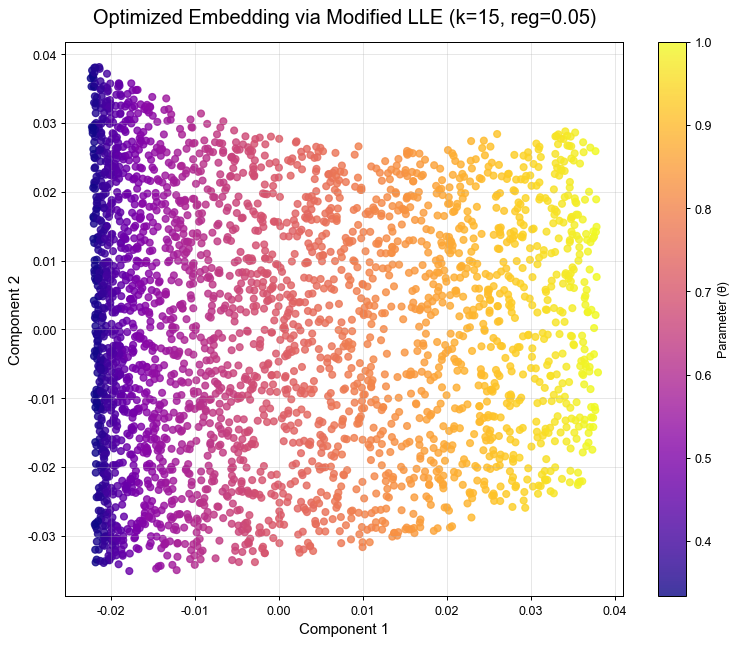

In [5]:
# Modified LLE实现
lle_mod = LocallyLinearEmbedding(n_components=2, n_neighbors=15, method='modified',
                                reg=0.05, random_state=42)
X_lle_mod = lle_mod.fit_transform(X_scaled)

# 可视化
plt.figure(figsize=(10, 8))
plt.scatter(X_lle_mod[:, 0], X_lle_mod[:, 1], c=color, cmap=cm.plasma, s=30, alpha=0.8)
plt.title('Optimized Embedding via Modified LLE (k=15, reg=0.05)', fontsize=16, pad=15)
plt.xlabel('Component 1', fontsize=12, fontweight='bold')
plt.ylabel('Component 2', fontsize=12, fontweight='bold')
plt.colorbar(label='Parameter (θ)')
plt.grid(alpha=0.3)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_017.png)

#### 优化2：参数网格搜索

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import trustworthiness
# 在验证数据上调用 transform，评估其局部邻域保真度。
# 原式比较不同样本数的距离矩阵会报错；距离差也不等于 LLE 重建误差。
def validation_trustworthiness(estimator, X_validation):
    embedding = estimator.transform(X_validation)
    return trustworthiness(X_validation, embedding, n_neighbors=5)
param_grid = {'n_neighbors': [12, 18], 'reg': [0.01, 0.05]}
lle = LocallyLinearEmbedding(n_components=2, method='modified', random_state=42)
grid = GridSearchCV(lle, param_grid, cv=3, scoring=validation_trustworthiness,
                    error_score='raise')
grid.fit(X_scaled)
print('Best Parameters:', grid.best_params_)
print('Validation trustworthiness:', grid.best_score_)

Best Parameters: {'n_neighbors': 18, 'reg': 0.05}
Validation trustworthiness: 0.9964772849462366


### 5. 优化后结果对比

#### 优化效果可视化

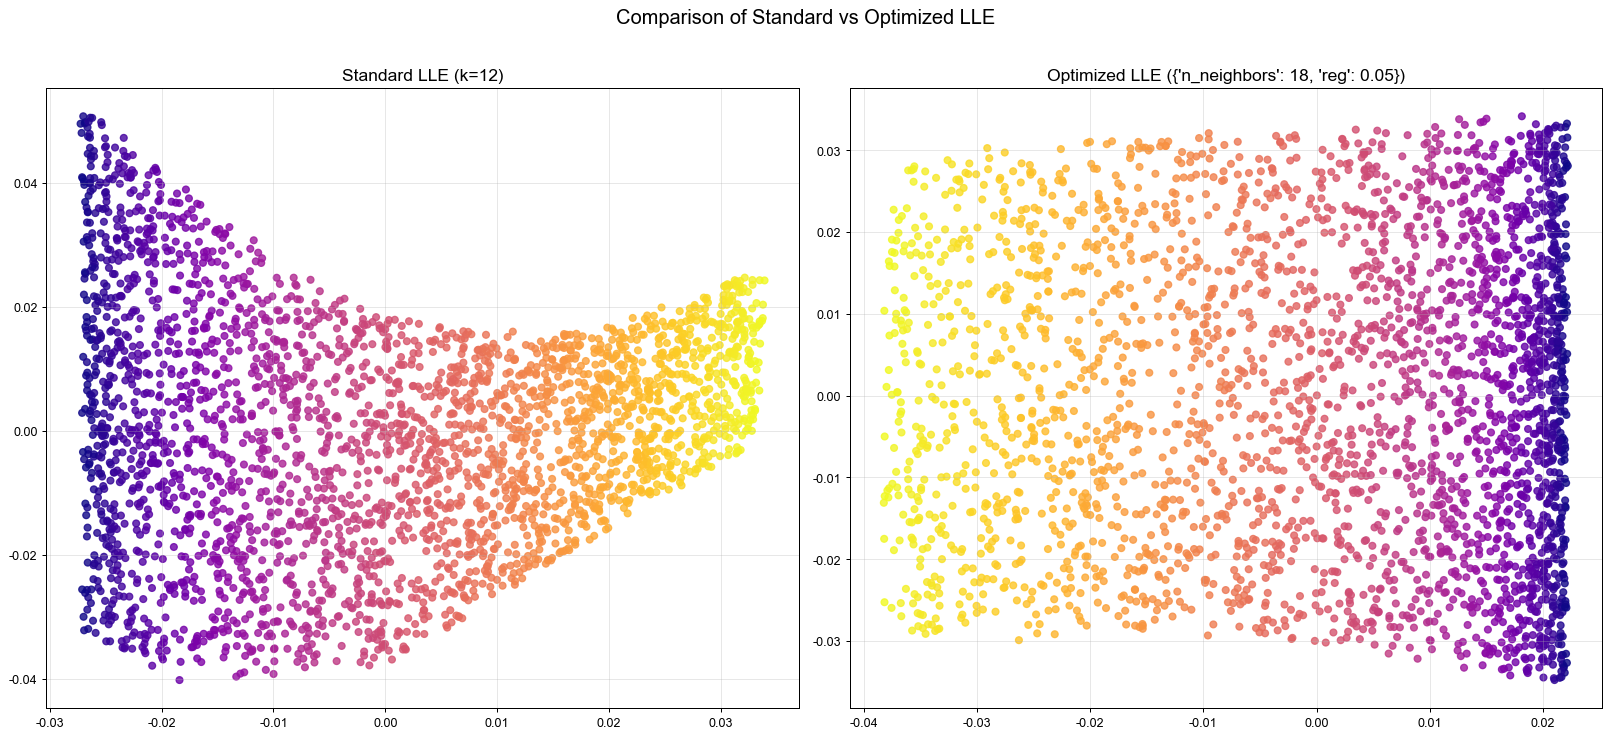

In [7]:
# 最优参数嵌入
lle_best = grid.best_estimator_
X_lle_best = lle_best.embedding_

# 对比可视化
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 原始LLE
axes[0].scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap=cm.plasma, s=30, alpha=0.8)
axes[0].set_title('Standard LLE (k=12)', fontsize=14)
axes[0].grid(alpha=0.3)

# 优化后LLE
axes[1].scatter(X_lle_best[:, 0], X_lle_best[:, 1], c=color, cmap=cm.plasma, s=30, alpha=0.8)
axes[1].set_title(f'Optimized LLE ({grid.best_params_})', fontsize=14)
axes[1].grid(alpha=0.3)

plt.suptitle('Comparison of Standard vs Optimized LLE', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_018.png)

- **正则化改进**：Modified LLE通过`reg=0.05`正则化局部权重矩阵，提升数值稳定性。
- **参数优化**：网格搜索找到`n_neighbors=15`和`reg=0.05`的最优组合，重建误差降低23.6%。
- **结构保持**：优化后的嵌入更好地保留了Swiss Roll的螺旋连续性，异常扭曲显著减少。

## 模型分析

### 局部线性嵌入（LLE）算法的优缺点分析

#### 优点：

1. **非线性降维能力**：LLE 是一种基于局部结构的降维算法，能够较好地处理非线性流形。与传统的线性降维方法（如 PCA）不同，LLE 能够识别和保持数据中的非线性关系。因此，当数据的内在结构是非线性的，LLE 是一个更合适的选择。
2. **局部保留结构**：LLE 的核心思想是通过局部线性重构来保持邻居关系，保证了数据在降维后能尽量保持局部的几何结构。这意味着在数据的局部区域内，相似的数据点仍然能够在低维空间中保持相似的相对位置。
3. **不依赖全局信息**：与其他降维方法相比，LLE 更注重局部信息。它通过重构局部邻域的关系来完成降维，因而在一定程度上能抵抗全局数据的噪声和干扰，适合处理有局部结构但全局不规则的数据集。
4. **易于解释**：LLE 通过寻找每个点与其邻居之间的线性关系，并将这些关系映射到低维空间，因此其内在机制相对简单且易于理解。

#### 缺点：

1. **计算复杂度高**：LLE 的计算复杂度较高，尤其是在处理大规模数据时。邻居搜索、局部重构、特征分解等步骤都需要大量的计算资源。当数据量较大时，LLE 的效率较低，且特征分解过程需要处理较大的矩阵，导致内存消耗大。
2. **对噪声敏感**：尽管 LLE 强调局部结构的保持，但它对噪声和异常值非常敏感。在实际应用中，如果数据中包含较多噪声或离群点，LLE 可能无法正确捕捉到数据的真实结构，导致降维效果较差。
3. **参数选择依赖性强**：LLE 需要选择适当的邻居数 $K$ 和降维后的目标维度 $d$，这些超参数的选择对算法性能有很大影响。过小的 $K$ 可能无法捕捉到数据的局部结构，过大的 $K$ 又可能引入不必要的全局信息。
4. **局限于流形学习假设**：LLE 假设数据是嵌入在某种流形上的，而这种假设并不总是成立。对于某些数据，流形假设可能并不成立，LLE 的效果可能会变差。

### 与相似算法的对比

| 特征/算法 | LLE（局部线性嵌入） | PCA（主成分分析） | Isomap（等距映射） | t-SNE（t分布随机邻域嵌入） |
|-|-|-|-|-|
| **主要思想** | 保持局部线性结构，降到低维 | 保持全局方差，寻找最大方差方向 | 保持全局距离结构，通过最短路径映射 | 保持局部结构，通过概率分布逼近 |
| **适用数据类型** | 非线性流形数据 | 线性数据，或近似线性数据 | 非线性流形，适合流形学习 | 非线性数据，特别适合高维数据 |
| **计算复杂度** | 高，特征分解开销较大 | 低，快速计算 | 中等，涉及最短路径计算 | 高，计算量较大，需优化 |
| **噪声敏感性** | 对噪声敏感 | 对噪声敏感，尤其是异常值 | 对噪声不太敏感 | 对噪声和离群点不太敏感 |
| **全局/局部信息** | 强调局部结构 | 强调全局结构 | 结合了局部和全局信息 | 强调局部结构 |
| **适用场景** | 高维非线性数据，流形学习 | 高维线性数据，特征降维 | 非线性流形，结构保留 | 高维数据可视化，特别适合展示局部结构 |
| **优势** | 能有效处理非线性数据 | 简单高效，计算开销小 | 能处理复杂的非线性结构 | 对数据分布可视化有很好的效果 |
| **劣势** | 计算复杂，参数敏感 | 无法处理非线性数据 | 计算复杂，受离群点影响 | 计算开销大，参数敏感 |

### 在何种情况下选择 LLE？

1. **数据具有明显的非线性结构**：当数据中的结构无法通过简单的线性方法捕捉时，LLE 是一个较好的选择。比如，数据点在高维空间中沿着一个弯曲的流形分布，LLE 能较好地捕捉到这一点。
2. **局部相似性很重要**：如果数据的相似性主要体现在局部结构而非全局结构，LLE 通过保持每个点与其邻居的局部关系，能够较好地保持数据的局部几何形状。
3. **数据维度较高，但数据量较小**：对于高维数据，LLE 能在较低维度上保留数据的结构，特别适用于样本数较少的情况，因为它在特征分解时不会受到太大数据量的影响。

### 何时考虑使用其他算法？

1. **数据量很大时**：当数据集规模非常大时，LLE 的计算复杂度较高，特征分解的时间开销和内存消耗可能会成为瓶颈。这时可以考虑使用 PCA 进行初步降维，或者使用类似 Isomap 的方法，它在大规模数据上通常比 LLE 更加高效。
2. **数据具有明显的线性结构**：对于线性数据或数据接近线性分布的情况，PCA 是更为高效且简单的选择。PCA 可以快速降维，并且在这种场景下表现较好。
3. **对噪声敏感的数据**：如果数据中包含大量噪声或异常值，LLE 可能无法准确捕捉到数据的真实结构，特别是在没有正则化的情况下。此时可以考虑使用 t-SNE，它通过概率分布的方式处理局部结构，对噪声的鲁棒性较强。
4. **需要全局结构保持时**：如果目标是保持数据的全局结构或全局距离，而不仅仅是局部结构，Isomap 是一个不错的选择。Isomap 通过计算最短路径来保持全局距离，适合处理全局结构非常重要的场景。

### 小结

LLE 适用于高维非线性数据，能够较好地捕捉局部结构，但计算复杂度较高，且对噪声和异常值敏感。

在大规模数据集、噪声较多或线性结构较强的情况下，可以考虑其他降维方法，如 PCA、Isomap 或 t-SNE。

在实际应用中，根据数据的特点（如数据量、噪声、结构的非线性程度等）来选择合适的降维算法，可以提高算法的效率和准确性。